# 📚 Task 3: Bias Detection in Children's Story Premises
### CSC8646 Assignment — Generative AI

This notebook analyses `premises.csv` (100 story premises) for potential biases including:
- **Gender bias** (character roles, descriptors)
- **Racial/Ethnic bias** (representation, stereotyping)
- **Cultural bias** (Western-centric themes, colonial narratives)
- **Theme bias** (conflict, justice, war dominance)
- **Character role bias** (protagonist vs antagonist demographics)

---

## 🔧 Step 1: Install & Import Libraries

In [1]:
# Install required libraries
!pip install -q pandas matplotlib seaborn nltk wordcloud textblob plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import nltk
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')
PALETTE = sns.color_palette('Set2')

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 📂 Step 2: Load the Dataset

In [4]:
# -------------------------------------------------------
# If running in Google Colab, upload premises.csv first:
# Click the folder icon on the left → Upload → select premises.csv
# Then run this cell.
# -------------------------------------------------------

# Load data — the CSV has no header, one story per row
df = pd.read_csv('premises.csv', header=None, names=['premise'])
df['premise'] = df['premise'].astype(str).str.strip().str.strip('"')
df['story_id'] = range(1, len(df) + 1)

print(f'✅ Loaded {len(df)} story premises')
print('\n--- Sample Premises ---')
df[['story_id', 'premise']].head(3)

✅ Loaded 100 story premises

--- Sample Premises ---


,story_id,premise
0,1,"In a quest for justice, a passionate and ideal..."
1,2,"In 1960s rural southern town, a determined you..."
2,3,"In 18th century Native American tribe, a young..."


## 🚻 Step 3: Gender Bias Analysis

           GENDER TERM FREQUENCY SUMMARY
  Total male references   : 180
  Total female references : 129
  Ratio (M:F)             : 1.40:1

Story gender dominance breakdown:
gender_label
Male-dominant      42
Female-dominant    31
Gender-neutral     22
Balanced            5


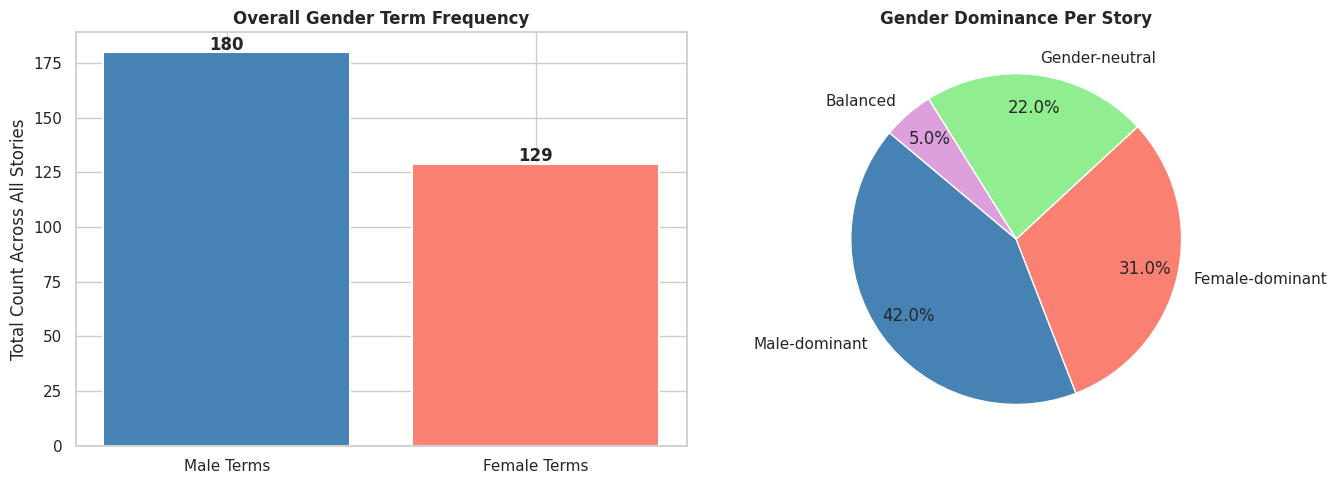

💾 Saved: gender_bias.png


In [5]:
# ── Define gendered keyword lists ──────────────────────────────────────────────
MALE_TERMS = [
    'he', 'him', 'his', 'man', 'men', 'boy', 'boys', 'male', 'father', 'son',
    'brother', 'husband', 'grandfather', 'uncle', 'king', 'prince', 'lord',
    'sir', 'mr', 'gentleman', 'guys', 'lad', 'groom'
]
FEMALE_TERMS = [
    'she', 'her', 'hers', 'woman', 'women', 'girl', 'girls', 'female', 'mother',
    'daughter', 'sister', 'wife', 'grandmother', 'aunt', 'queen', 'princess',
    'lady', 'ms', 'mrs', 'miss', 'madam', 'bride'
]

# Adjectives commonly associated with each gender in stories
MALE_ADJECTIVES   = ['strong', 'brave', 'powerful', 'stoic', 'rational', 'aggressive',
                     'dominant', 'ambitious', 'bold', 'tough', 'resilient', 'cunning']
FEMALE_ADJECTIVES = ['gentle', 'nurturing', 'compassionate', 'emotional', 'sensitive',
                     'caring', 'kind', 'beautiful', 'delicate', 'passive', 'romantic', 'warm']

def count_terms(text, terms):
    text_lower = text.lower()
    return sum(len(re.findall(r'\b' + t + r'\b', text_lower)) for t in terms)

df['male_count']        = df['premise'].apply(lambda x: count_terms(x, MALE_TERMS))
df['female_count']      = df['premise'].apply(lambda x: count_terms(x, FEMALE_TERMS))
df['male_adj_count']    = df['premise'].apply(lambda x: count_terms(x, MALE_ADJECTIVES))
df['female_adj_count']  = df['premise'].apply(lambda x: count_terms(x, FEMALE_ADJECTIVES))

# Classify gender prominence per story
def gender_label(row):
    if row['male_count'] > row['female_count']: return 'Male-dominant'
    elif row['female_count'] > row['male_count']: return 'Female-dominant'
    elif row['male_count'] == 0 and row['female_count'] == 0: return 'Gender-neutral'
    else: return 'Balanced'

df['gender_label'] = df.apply(gender_label, axis=1)

# ── Summary ────────────────────────────────────────────────────────────────────
total_male   = df['male_count'].sum()
total_female = df['female_count'].sum()
print('='*55)
print('           GENDER TERM FREQUENCY SUMMARY')
print('='*55)
print(f'  Total male references   : {total_male}')
print(f'  Total female references : {total_female}')
print(f'  Ratio (M:F)             : {total_male/total_female:.2f}:1')
print('\nStory gender dominance breakdown:')
print(df['gender_label'].value_counts().to_string())

# ── Plot 1: Gender term counts ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar — overall totals
axes[0].bar(['Male Terms', 'Female Terms'], [total_male, total_female],
             color=['steelblue', 'salmon'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Overall Gender Term Frequency', fontweight='bold')
axes[0].set_ylabel('Total Count Across All Stories')
for i, v in enumerate([total_male, total_female]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie — gender dominance distribution
label_counts = df['gender_label'].value_counts()
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'salmon', 'lightgreen', 'plum'],
            startangle=140, pctdistance=0.8)
axes[1].set_title('Gender Dominance Per Story', fontweight='bold')

plt.tight_layout()
plt.savefig('gender_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: gender_bias.png')

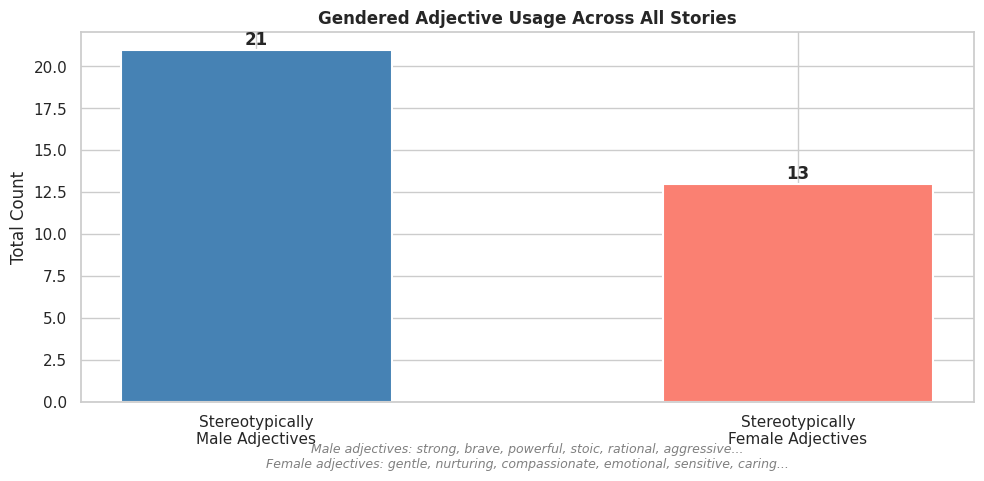

💾 Saved: gendered_adjectives.png


In [6]:
# ── Plot 2: Male vs Female adjective associations ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

total_male_adj   = df['male_adj_count'].sum()
total_female_adj = df['female_adj_count'].sum()

bars = ax.bar(
    ['Stereotypically\nMale Adjectives', 'Stereotypically\nFemale Adjectives'],
    [total_male_adj, total_female_adj],
    color=['steelblue', 'salmon'], edgecolor='white', linewidth=1.5, width=0.5
)
ax.set_title('Gendered Adjective Usage Across All Stories', fontweight='bold')
ax.set_ylabel('Total Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontweight='bold')

note = ('Male adjectives: ' + ', '.join(MALE_ADJECTIVES[:6]) + '...\n' +
        'Female adjectives: ' + ', '.join(FEMALE_ADJECTIVES[:6]) + '...')
ax.text(0.5, -0.18, note, transform=ax.transAxes, ha='center',
        fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('gendered_adjectives.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: gendered_adjectives.png')

## 🌍 Step 4: Racial & Ethnic Representation Analysis

   ETHNIC/RACIAL GROUP REPRESENTATION IN STORIES
                              stories_count
Caucasian / White / European             38
African American / Black                 25
Indigenous / Native                      18
Asian / East Asian                       11
Latino / Hispanic                         5
South Asian                               3
Middle Eastern / Arab                     3
Mixed / Mestizo                           3


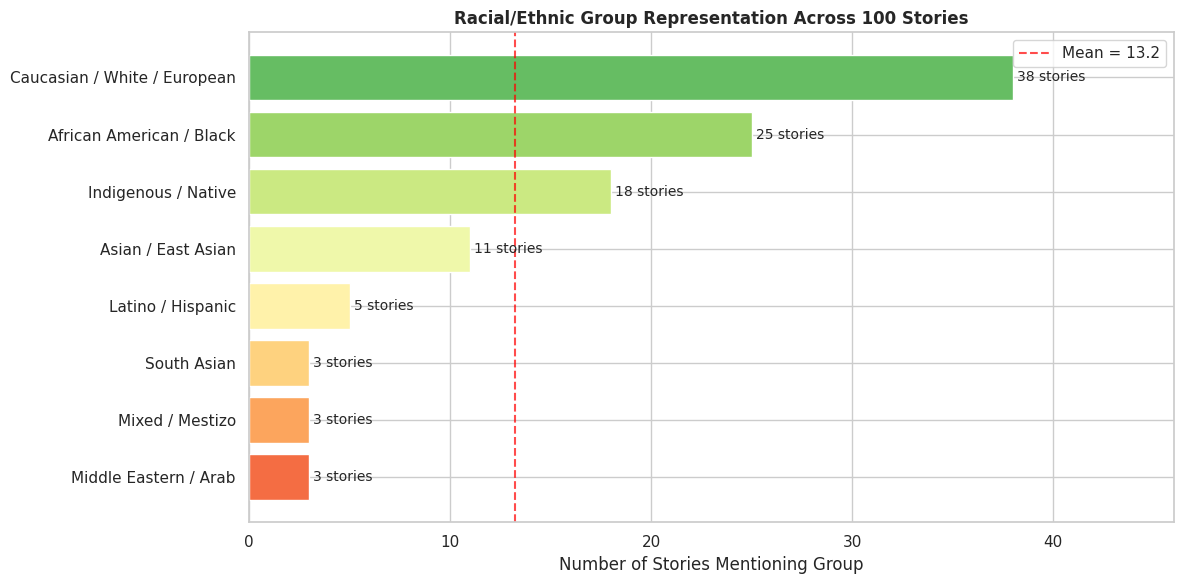

💾 Saved: ethnic_representation.png


In [7]:
# ── Ethnicity/race keyword groups ──────────────────────────────────────────────
ETHNIC_GROUPS = {
    'African American / Black': [
        'african american', 'black', 'afro', 'negro', 'african'
    ],
    'Caucasian / White / European': [
        'caucasian', 'white', 'european', 'british', 'french', 'german',
        'dutch', 'belgian', 'russian', 'italian', 'spanish', 'portuguese'
    ],
    'Latino / Hispanic': [
        'latino', 'latina', 'hispanic', 'mexican', 'latin'
    ],
    'Asian / East Asian': [
        'asian', 'chinese', 'japanese', 'korean', 'vietnamese', 'thai',
        'javanese', 'indonesian'
    ],
    'South Asian': [
        'indian', 'pakistani', 'bangladeshi', 'sri lankan', 'south asian'
    ],
    'Middle Eastern / Arab': [
        'arab', 'middle eastern', 'iraqi', 'iranian', 'persian', 'afghan',
        'arabic'
    ],
    'Indigenous / Native': [
        'native american', 'indigenous', 'aboriginal', 'native alaskan',
        'first nations', 'tribal', 'tribe'
    ],
    'Mixed / Mestizo': [
        'mestizo', 'mixed', 'biracial', 'multiracial'
    ]
}

def count_ethnic(text, keywords):
    text_lower = text.lower()
    return sum(1 for kw in keywords if kw in text_lower)

# Count stories mentioning each group (at least once)
ethnic_story_counts = {}
for group, keywords in ETHNIC_GROUPS.items():
    col = f'eth_{group[:8]}'
    df[col] = df['premise'].apply(lambda x: 1 if count_ethnic(x, keywords) > 0 else 0)
    ethnic_story_counts[group] = df[col].sum()

ethnic_df = pd.DataFrame.from_dict(ethnic_story_counts, orient='index',
                                    columns=['stories_count'])
ethnic_df = ethnic_df.sort_values('stories_count', ascending=True)

print('='*55)
print('   ETHNIC/RACIAL GROUP REPRESENTATION IN STORIES')
print('='*55)
print(ethnic_df.sort_values('stories_count', ascending=False).to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(ethnic_df)))
bars = ax.barh(ethnic_df.index, ethnic_df['stories_count'], color=colors, edgecolor='white')

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(width)} stories', va='center', fontsize=10)

ax.set_title('Racial/Ethnic Group Representation Across 100 Stories', fontweight='bold')
ax.set_xlabel('Number of Stories Mentioning Group')
ax.set_xlim(0, ethnic_df['stories_count'].max() + 8)
ax.axvline(x=ethnic_df['stories_count'].mean(), color='red', linestyle='--',
           alpha=0.7, label=f'Mean = {ethnic_df["stories_count"].mean():.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('ethnic_representation.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: ethnic_representation.png')

## 🗺️ Step 5: Geographical & Cultural Bias

       GEOGRAPHICAL SETTING DISTRIBUTION
                         count
North America               52
Europe (Western)            32
Africa                      32
Asia (East/South-East)      10
South Asia                   5
Middle East                  5
Fictional / Unspecified      5
Latin America                3
Oceania / Pacific            3
Russia / Siberia             2


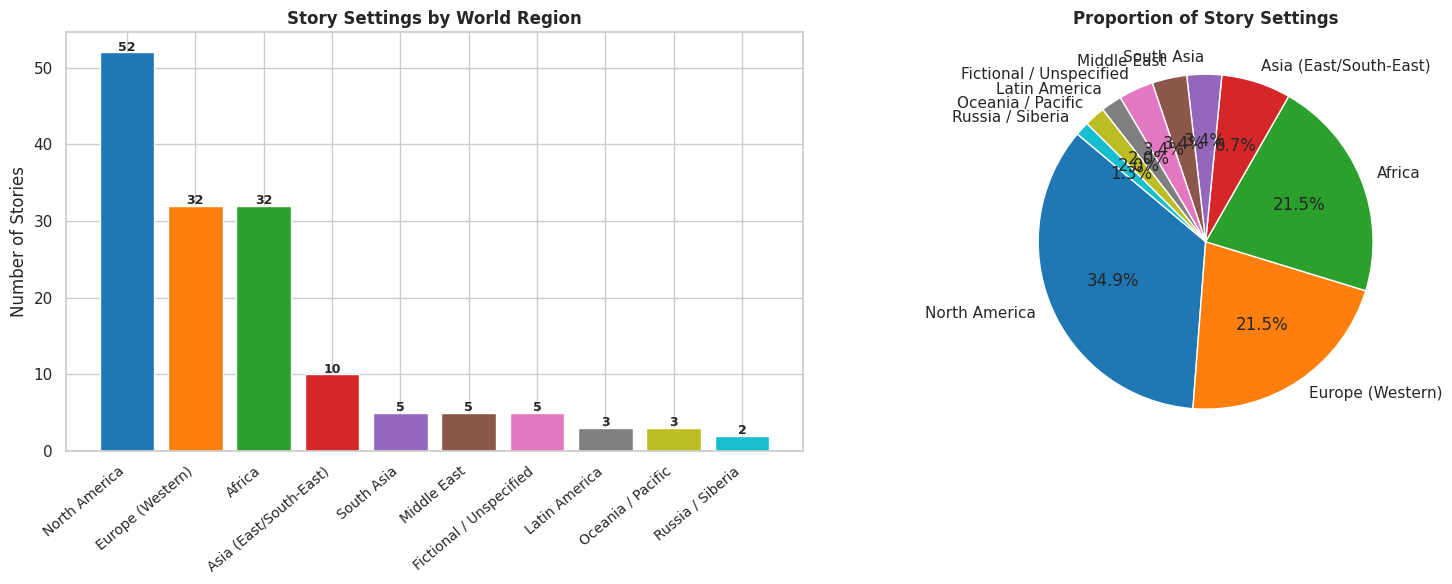

💾 Saved: geographic_bias.png


In [8]:
# ── Setting/location keyword groups ────────────────────────────────────────────
GEO_GROUPS = {
    'North America': ['american', 'united states', 'usa', 'canada', 'midwest',
                      'detroit', 'border town', 'us '],
    'Europe (Western)': ['french', 'british', 'english', 'german', 'dutch',
                          'belgian', 'italian', 'spanish', 'paris', 'london',
                          'renaissance', 'roman', 'ancient rome'],
    'Africa': ['africa', 'african', 'congo', 'algerian', 'algeria', 'kenya',
               'nigeria', 'sub-saharan'],
    'Asia (East/South-East)': ['japan', 'japanese', 'tokyo', 'china', 'chinese',
                                'indonesia', 'indonesian', 'javanese', 'vietnam'],
    'South Asia': ['india', 'indian', 'colonial india', 'mughal', 'pakistan'],
    'Middle East': ['middle east', 'iraq', 'iraqi', 'afghanistan', 'iran',
                    'persian', 'arab'],
    'Latin America': ['latin america', 'mexico', 'colombia', 'brazil',
                      'south america', 'central america'],
    'Russia / Siberia': ['russia', 'russian', 'siberia', 'siberian', 'soviet'],
    'Oceania / Pacific': ['pacific', 'australia', 'new zealand', 'polynesia'],
    'Fictional / Unspecified': ['kingdom', 'realm', 'village', 'fantasy', 'distant land']
}

geo_counts = {}
for region, keywords in GEO_GROUPS.items():
    geo_counts[region] = df['premise'].apply(
        lambda x: 1 if any(kw in x.lower() for kw in keywords) else 0
    ).sum()

geo_df = pd.DataFrame.from_dict(geo_counts, orient='index', columns=['count'])
geo_df = geo_df.sort_values('count', ascending=False)

print('='*50)
print('       GEOGRAPHICAL SETTING DISTRIBUTION')
print('='*50)
print(geo_df.to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
color_map = plt.cm.tab10(np.linspace(0, 1, len(geo_df)))
axes[0].bar(geo_df.index, geo_df['count'], color=color_map, edgecolor='white')
axes[0].set_xticklabels(geo_df.index, rotation=40, ha='right', fontsize=10)
axes[0].set_title('Story Settings by World Region', fontweight='bold')
axes[0].set_ylabel('Number of Stories')
for i, v in enumerate(geo_df['count']):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontsize=9, fontweight='bold')

# Pie chart
non_zero = geo_df[geo_df['count'] > 0]
axes[1].pie(non_zero['count'], labels=non_zero.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.tab10(np.linspace(0, 1, len(non_zero))))
axes[1].set_title('Proportion of Story Settings', fontweight='bold')

plt.tight_layout()
plt.savefig('geographic_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: geographic_bias.png')

## ⚔️ Step 6: Theme & Narrative Bias

        THEME FREQUENCY ACROSS ALL STORIES
                       count
Adventure / Quest         58
Family / Identity         43
War / Military            39
Corruption / Power        38
Morality / Ethics         32
Justice / Law             29
Colonialism               29
Romance / Love            18
Social Justice / Race     13
Redemption / Growth        9


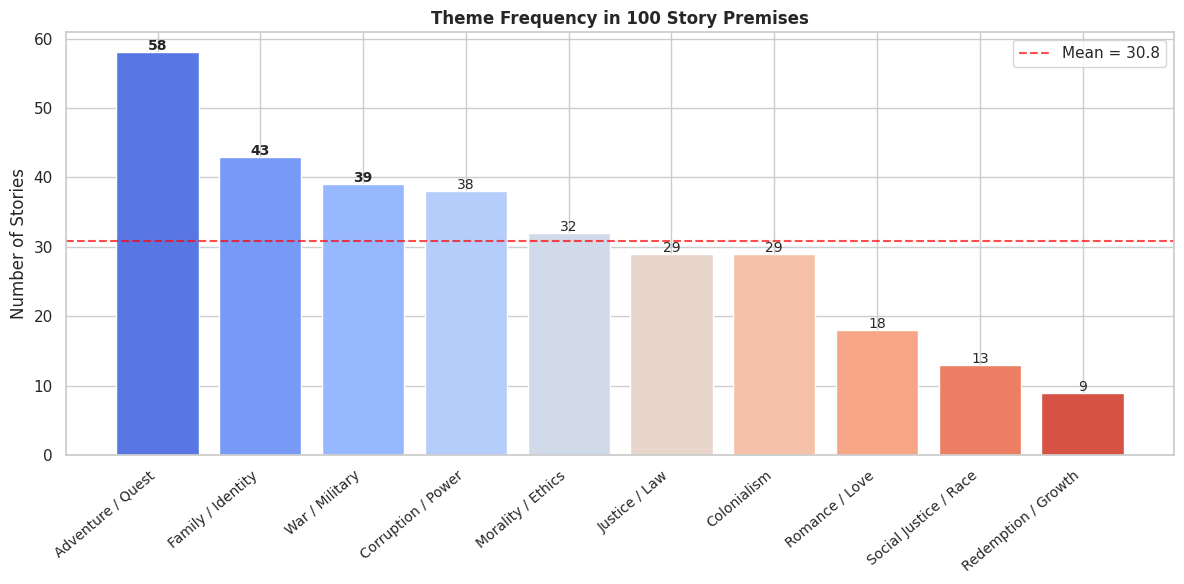

💾 Saved: theme_bias.png


In [9]:
# ── Define themes ──────────────────────────────────────────────────────────────
THEMES = {
    'Justice / Law': ['justice', 'lawyer', 'court', 'trial', 'conviction',
                       'judge', 'law', 'legal', 'prosecutor', 'attorney', 'crime'],
    'War / Military': ['war', 'military', 'soldier', 'battle', 'combat',
                        'weapon', 'mission', 'army', 'navy', 'troops', 'conflict'],
    'Colonialism': ['colonial', 'colonialism', 'empire', 'colony', 'imperial',
                     'colonizer', 'colonist', 'independence', 'oppressed', 'exploitation'],
    'Romance / Love': ['love', 'romantic', 'romance', 'relationship', 'forbidden love',
                        'bond', 'affection', 'marriage', 'heart'],
    'Family / Identity': ['family', 'father', 'mother', 'heritage', 'identity',
                            'ancestry', 'tradition', 'culture', 'legacy'],
    'Corruption / Power': ['corruption', 'corrupt', 'power', 'conspiracy',
                             'political', 'deceit', 'betrayal', 'manipulation'],
    'Social Justice / Race': ['discrimination', 'racism', 'racial', 'segregation',
                               'equality', 'rights', 'prejudice', 'oppression'],
    'Redemption / Growth': ['redemption', 'forgiveness', 'growth', 'overcome',
                             'healing', 'reconciliation', 'transformation'],
    'Adventure / Quest': ['quest', 'adventure', 'journey', 'explore', 'discover',
                            'mission', 'expedition', 'pursuit'],
    'Morality / Ethics': ['moral', 'ethics', 'ethical', 'dilemma', 'conscience',
                           'humanity', 'compassion', 'integrity']
}

theme_counts = {}
for theme, keywords in THEMES.items():
    theme_counts[theme] = df['premise'].apply(
        lambda x: 1 if any(kw in x.lower() for kw in keywords) else 0
    ).sum()

theme_df = pd.DataFrame.from_dict(theme_counts, orient='index', columns=['count'])
theme_df = theme_df.sort_values('count', ascending=False)

print('='*50)
print('        THEME FREQUENCY ACROSS ALL STORIES')
print('='*50)
print(theme_df.to_string())

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(theme_df)))
bars = ax.bar(theme_df.index, theme_df['count'], color=colors, edgecolor='white')
ax.set_xticklabels(theme_df.index, rotation=40, ha='right', fontsize=10)
ax.set_title('Theme Frequency in 100 Story Premises', fontweight='bold')
ax.set_ylabel('Number of Stories')

# Highlight top 3
for i, (bar, val) in enumerate(zip(bars, theme_df['count'])):
    weight = 'bold' if i < 3 else 'normal'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=10, fontweight=weight)

ax.axhline(y=theme_df['count'].mean(), color='red', linestyle='--',
            alpha=0.7, label=f'Mean = {theme_df["count"].mean():.1f}')
ax.legend()

plt.tight_layout()
plt.savefig('theme_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: theme_bias.png')

## 🦸 Step 7: Protagonist Gender & Role Bias

    ESTIMATED PROTAGONIST GENDER DISTRIBUTION
protagonist_gender
Male       75
Female     23
Unknown     2

  M:F Protagonist Ratio = 75:23  (3.26:1)


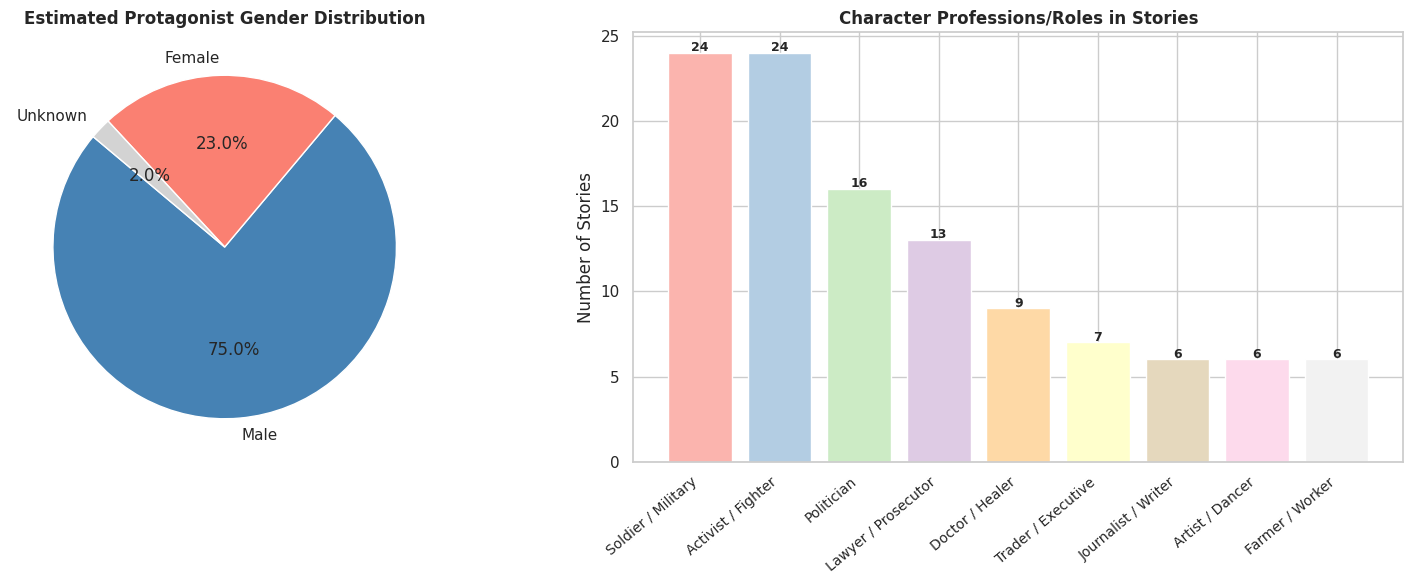

💾 Saved: protagonist_roles.png


In [10]:
# ── Detect protagonist gender using first character description ────────────────
# We look at which gender terms appear earliest in each premise

def protagonist_gender(text):
    text_lower = text.lower()
    male_positions   = [text_lower.find(t) for t in
                        ['he ', 'him ', 'his ', ' man ', 'young man', 'male', 'boy ']
                        if text_lower.find(t) != -1]
    female_positions = [text_lower.find(t) for t in
                        ['she ', 'her ', 'hers', ' woman ', 'young woman', 'female', 'girl ']
                        if text_lower.find(t) != -1]

    first_male   = min(male_positions)   if male_positions   else float('inf')
    first_female = min(female_positions) if female_positions else float('inf')

    if first_male == float('inf') and first_female == float('inf'): return 'Unknown'
    elif first_male < first_female:   return 'Male'
    elif first_female < first_male:   return 'Female'
    else:                             return 'Ambiguous'

df['protagonist_gender'] = df['premise'].apply(protagonist_gender)

proto_counts = df['protagonist_gender'].value_counts()

print('='*45)
print('    ESTIMATED PROTAGONIST GENDER DISTRIBUTION')
print('='*45)
print(proto_counts.to_string())
male_p   = proto_counts.get('Male', 0)
female_p = proto_counts.get('Female', 0)
if female_p > 0:
    print(f'\n  M:F Protagonist Ratio = {male_p}:{female_p}  ({male_p/female_p:.2f}:1)')

# ── Profession / role analysis ─────────────────────────────────────────────────
ROLES = {
    'Lawyer / Prosecutor': ['lawyer', 'prosecutor', 'attorney', 'legal'],
    'Soldier / Military': ['soldier', 'military', 'officer', 'pilot', 'medic', 'sailor'],
    'Journalist / Writer': ['journalist', 'reporter', 'writer', 'scholar'],
    'Doctor / Healer': ['doctor', 'medic', 'healer', 'physician', 'chaplain'],
    'Artist / Dancer': ['artist', 'dancer', 'painter', 'sculptor'],
    'Politician': ['politician', 'administrator', 'governor', 'official'],
    'Trader / Executive': ['trader', 'executive', 'businessman', 'merchant'],
    'Farmer / Worker': ['farmer', 'worker', 'laborer'],
    'Activist / Fighter': ['activist', 'rebel', 'fighter', 'resistance', 'revolutionary']
}

role_counts = {}
for role, keywords in ROLES.items():
    role_counts[role] = df['premise'].apply(
        lambda x: 1 if any(kw in x.lower() for kw in keywords) else 0
    ).sum()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Protagonist gender pie
axes[0].pie(proto_counts.values, labels=proto_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=['steelblue', 'salmon', 'lightgray', 'plum'])
axes[0].set_title('Estimated Protagonist Gender Distribution', fontweight='bold')

# Role distribution bar
role_df = pd.Series(role_counts).sort_values(ascending=False)
colors  = plt.cm.Pastel1(np.linspace(0, 1, len(role_df)))
axes[1].bar(role_df.index, role_df.values, color=colors, edgecolor='white')
axes[1].set_xticklabels(role_df.index, rotation=40, ha='right', fontsize=10)
axes[1].set_title('Character Professions/Roles in Stories', fontweight='bold')
axes[1].set_ylabel('Number of Stories')
for i, v in enumerate(role_df.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('protagonist_roles.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: protagonist_roles.png')

## 😊 Step 8: Sentiment Analysis by Group

  AVERAGE SENTIMENT SCORE BY PROTAGONIST GENDER
protagonist_gender
Unknown   -0.090972
Male      -0.004246
Female     0.045208

Overall sentiment distribution:
sentiment_label
Neutral     53
Positive    26
Negative    21

Overall average sentiment: 0.0054


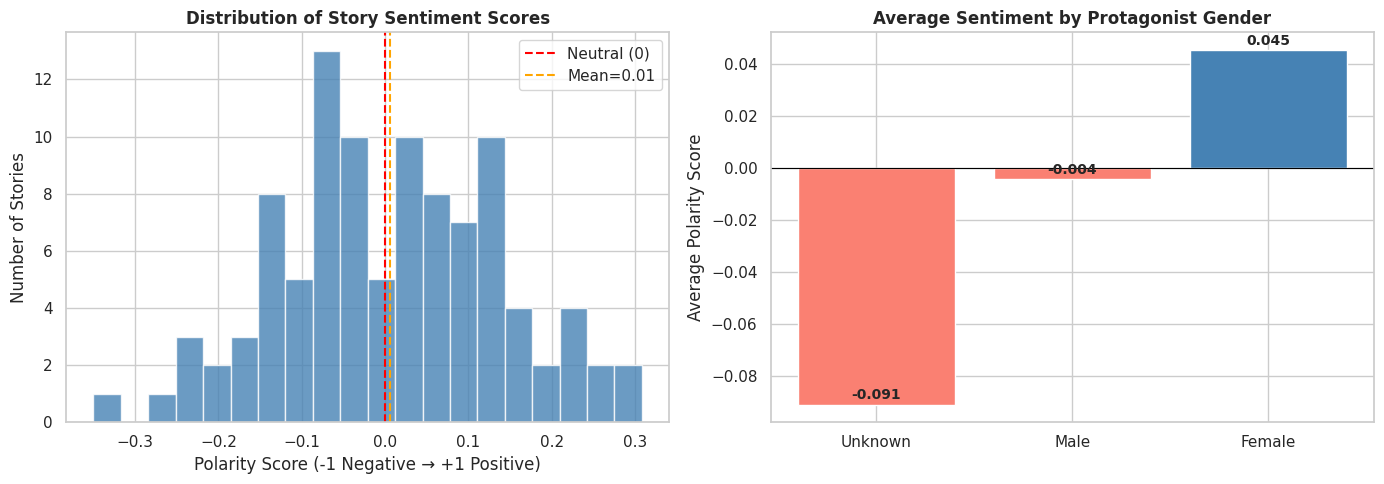

💾 Saved: sentiment_analysis.png


In [11]:
# ── Sentiment per story ────────────────────────────────────────────────────────
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity   # -1 (negative) to +1 (positive)

df['sentiment'] = df['premise'].apply(get_sentiment)

def sentiment_label(score):
    if score > 0.1:   return 'Positive'
    elif score < -0.1: return 'Negative'
    else:              return 'Neutral'

df['sentiment_label'] = df['sentiment'].apply(sentiment_label)

# Sentiment by protagonist gender
sent_by_gender = df.groupby('protagonist_gender')['sentiment'].mean().sort_values()

print('='*50)
print('  AVERAGE SENTIMENT SCORE BY PROTAGONIST GENDER')
print('='*50)
print(sent_by_gender.to_string())
print('\nOverall sentiment distribution:')
print(df['sentiment_label'].value_counts().to_string())
print(f'\nOverall average sentiment: {df["sentiment"].mean():.4f}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all sentiments
axes[0].hist(df['sentiment'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', label='Neutral (0)')
axes[0].axvline(df['sentiment'].mean(), color='orange', linestyle='--',
                 label=f'Mean={df["sentiment"].mean():.2f}')
axes[0].set_title('Distribution of Story Sentiment Scores', fontweight='bold')
axes[0].set_xlabel('Polarity Score (-1 Negative → +1 Positive)')
axes[0].set_ylabel('Number of Stories')
axes[0].legend()

# Sentiment by gender
colors = ['steelblue' if v >= 0 else 'salmon' for v in sent_by_gender.values]
axes[1].bar(sent_by_gender.index, sent_by_gender.values, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Sentiment by Protagonist Gender', fontweight='bold')
axes[1].set_ylabel('Average Polarity Score')
for i, v in enumerate(sent_by_gender.values):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: sentiment_analysis.png')

## ☁️ Step 9: Word Cloud — Most Common Words

Top 25 Most Frequent Words:
         word  count
        young     52
      justice     37
   determined     35
     discover     30
     american     29
      african     26
       family     24
         true     22
     colonial     21
     confront     20
       people     20
   corruption     18
         male     18
      century     17
    community     17
     navigate     16
        local     15
       leader     15
   struggling     15
        forms     15
      loyalty     15
       female     14
disillusioned     14
       within     14
    discovers     14


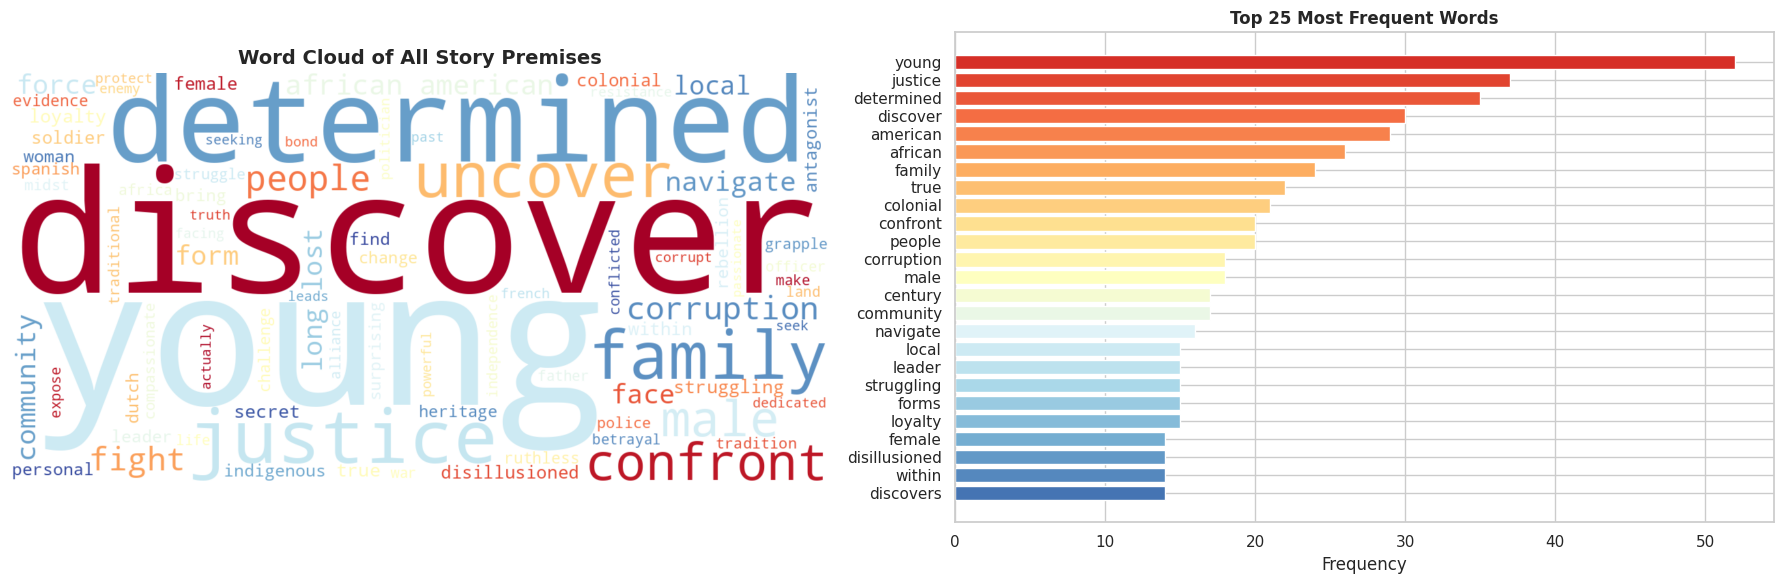

💾 Saved: wordcloud.png


In [14]:
stop_words = set(stopwords.words('english'))
extra_stops = {'one', 'also', 'would', 'could', 'must', 'get', 'may', 'take',
               'lead', 'leading', 'ultimately', 'forcing', 'story', 'new', 'two'}
stop_words.update(extra_stops)

all_text = ' '.join(df['premise'].tolist()).lower()
tokens   = word_tokenize(all_text)
filtered = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 3]

freq = Counter(filtered)
top_words = pd.DataFrame(freq.most_common(25), columns=['word', 'count'])

print('Top 25 Most Frequent Words:')
print(top_words.to_string(index=False))

# ── Word Cloud ────────────────────────────────────────────────────────────────
wc = WordCloud(width=1200, height=600, background_color='white',
               colormap='RdYlBu', max_words=80,
               stopwords=stop_words).generate(all_text)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud of All Story Premises', fontweight='bold', fontsize=14)

# Top 25 bar chart
colors = plt.cm.RdYlBu(np.linspace(0.1, 0.9, len(top_words)))
axes[1].barh(top_words['word'][::-1], top_words['count'][::-1], color=colors[::-1])
axes[1].set_title('Top 25 Most Frequent Words', fontweight='bold')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: wordcloud.png')

## 🏛️ Step 10: Colonial Narrative Bias Detection

         COLONIAL NARRATIVE ANALYSIS
  Stories with colonial themes  : 37
  Told from colonizer POV       : 28
  Told from colonized POV       : 9

📖 Stories with Colonial Themes:
  Story   3: In 18th century Native American tribe, a young member struggles to balance tradition and modernity as they face the deci...
  Story   6: In 18th century Dutch colonial Indonesia, a young Dutch trader sent to work for the Dutch East India Company begins to q...
  Story  10: In 19th century French colonial Algeria, a disillusioned French journalist, determined to advocate for the rights of the...
  Story  14: In 19th century Belgian colonial Congo, a young Congolese man, deeply conflicted by his desire to protect his people and...
  Story  15: In 16th century Spanish-ruled America, a rebellious mestizo man, torn between his indigenous heritage and loyalty to the...
  Story  22: A young Dutch soldier, disillusioned by the brutality of the Dutch colonization of South Africa, forms an unlikely bond ..

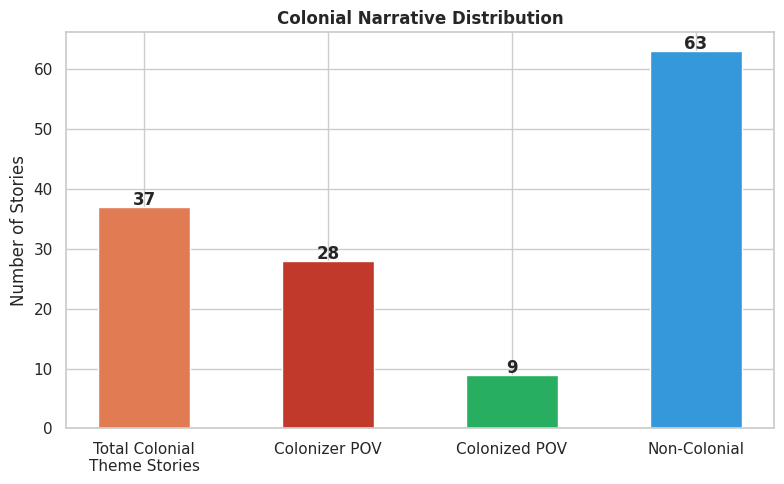

💾 Saved: colonial_bias.png


In [15]:
# ── Identify stories with colonial themes and perspective ──────────────────────
COLONIAL_KEYWORDS = ['colonial', 'colony', 'colonialism', 'empire', 'imperial',
                      'dutch east india', 'scramble for africa', 'british raj',
                      'colonizer', 'oppressed', 'native', 'indigenous', 'resistance',
                      'independence', 'exploitation', 'subjugation']

COLONIZER_PERSPECTIVE = ['dutch', 'british', 'french', 'german', 'belgian',
                          'spanish', 'portuguese', 'russian', 'european']

df['is_colonial']    = df['premise'].apply(
    lambda x: any(kw in x.lower() for kw in COLONIAL_KEYWORDS)).astype(int)
df['colonizer_pov']  = df.apply(
    lambda row: 1 if row['is_colonial'] and
    any(kw in row['premise'].lower() for kw in COLONIZER_PERSPECTIVE) else 0, axis=1)
df['colonized_pov']  = df['is_colonial'] - df['colonizer_pov']
df['colonized_pov']  = df['colonized_pov'].clip(lower=0)

n_colonial       = df['is_colonial'].sum()
n_colonizer_pov  = df['colonizer_pov'].sum()
n_colonized_pov  = df['colonized_pov'].sum()

print('='*55)
print('         COLONIAL NARRATIVE ANALYSIS')
print('='*55)
print(f'  Stories with colonial themes  : {n_colonial}')
print(f'  Told from colonizer POV       : {n_colonizer_pov}')
print(f'  Told from colonized POV       : {n_colonized_pov}')

# Show the colonial stories
print('\n📖 Stories with Colonial Themes:')
colonial_stories = df[df['is_colonial'] == 1][['story_id', 'premise']]
for _, row in colonial_stories.iterrows():
    preview = row['premise'][:120] + '...'
    print(f"  Story {row['story_id']:>3}: {preview}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['Total Colonial\nTheme Stories', 'Colonizer POV', 'Colonized POV', 'Non-Colonial']
values     = [n_colonial, n_colonizer_pov, n_colonized_pov, 100 - n_colonial]
colors     = ['#e07b54', '#c0392b', '#27ae60', '#3498db']
bars = ax.bar(categories, values, color=colors, edgecolor='white', width=0.5)
ax.set_title('Colonial Narrative Distribution', fontweight='bold')
ax.set_ylabel('Number of Stories')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('colonial_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: colonial_bias.png')

## 📊 Step 11: Comprehensive Bias Summary Dashboard

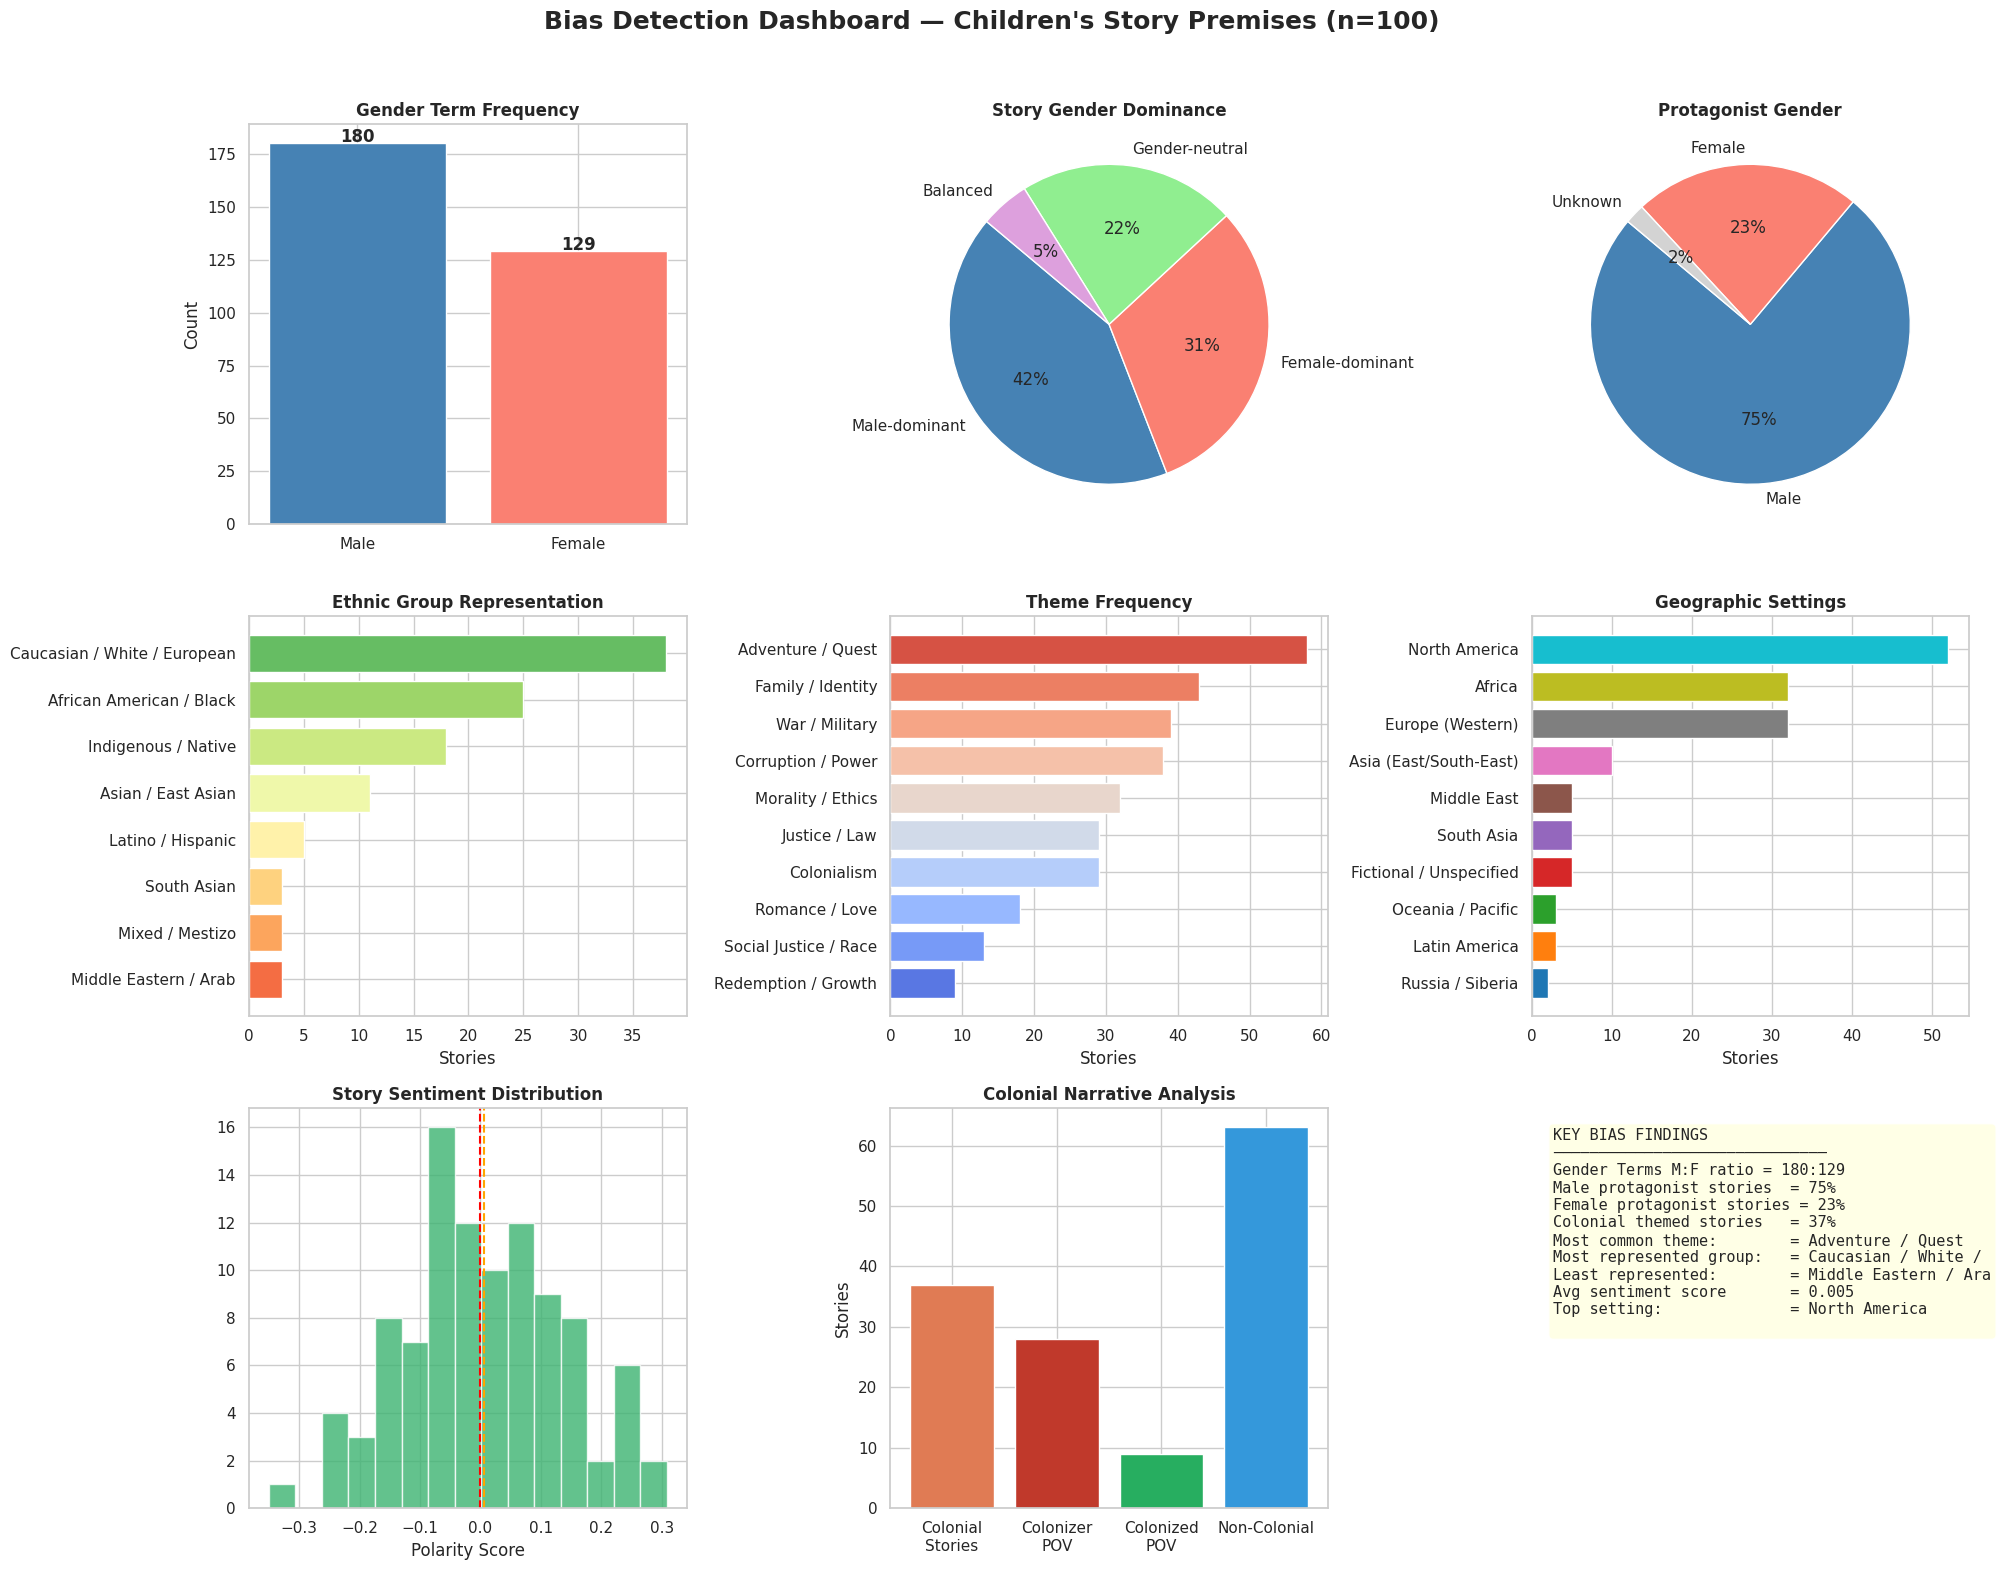

💾 Saved: bias_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Bias Detection Dashboard — Children\'s Story Premises (n=100)',
             fontsize=18, fontweight='bold', y=0.98)

# ── 1. Gender terms ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
ax1.bar(['Male', 'Female'], [total_male, total_female],
        color=['steelblue', 'salmon'], edgecolor='white')
ax1.set_title('Gender Term Frequency', fontweight='bold')
ax1.set_ylabel('Count')
for i, v in enumerate([total_male, total_female]):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# ── 2. Gender dominance pie ────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
label_counts_local = df['gender_label'].value_counts()
ax2.pie(label_counts_local.values, labels=label_counts_local.index,
        autopct='%1.0f%%', startangle=140,
        colors=['steelblue', 'salmon', 'lightgreen', 'plum'])
ax2.set_title('Story Gender Dominance', fontweight='bold')

# ── 3. Protagonist gender ──────────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
proto_local = df['protagonist_gender'].value_counts()
ax3.pie(proto_local.values, labels=proto_local.index, autopct='%1.0f%%',
        startangle=140, colors=['steelblue', 'salmon', 'lightgray', 'plum'])
ax3.set_title('Protagonist Gender', fontweight='bold')

# ── 4. Ethnic representation ───────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
eth_top = ethnic_df.sort_values('stories_count', ascending=True)
colors4 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(eth_top)))
ax4.barh(eth_top.index, eth_top['stories_count'], color=colors4, edgecolor='white')
ax4.set_title('Ethnic Group Representation', fontweight='bold')
ax4.set_xlabel('Stories')

# ── 5. Theme frequency ─────────────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
colors5 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(theme_df)))
ax5.barh(theme_df.index[::-1], theme_df['count'][::-1], color=colors5, edgecolor='white')
ax5.set_title('Theme Frequency', fontweight='bold')
ax5.set_xlabel('Stories')

# ── 6. Geographic setting ──────────────────────────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
geo_top = geo_df[geo_df['count'] > 0].sort_values('count', ascending=True)
colors6 = plt.cm.tab10(np.linspace(0, 1, len(geo_top)))
ax6.barh(geo_top.index, geo_top['count'], color=colors6, edgecolor='white')
ax6.set_title('Geographic Settings', fontweight='bold')
ax6.set_xlabel('Stories')

# ── 7. Sentiment distribution ──────────────────────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
ax7.hist(df['sentiment'], bins=15, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax7.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax7.axvline(df['sentiment'].mean(), color='orange', linestyle='--', linewidth=1.5)
ax7.set_title('Story Sentiment Distribution', fontweight='bold')
ax7.set_xlabel('Polarity Score')

# ── 8. Colonial breakdown ──────────────────────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
ax8.bar(['Colonial\nStories', 'Colonizer\nPOV', 'Colonized\nPOV', 'Non-Colonial'],
        [n_colonial, n_colonizer_pov, n_colonized_pov, 100 - n_colonial],
        color=['#e07b54', '#c0392b', '#27ae60', '#3498db'], edgecolor='white')
ax8.set_title('Colonial Narrative Analysis', fontweight='bold')
ax8.set_ylabel('Stories')

# ── 9. Bias Score Summary (text) ───────────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
ax9.axis('off')

m_prot  = df['protagonist_gender'].value_counts().get('Male', 0)
f_prot  = df['protagonist_gender'].value_counts().get('Female', 0)
summary_text = (
    f"KEY BIAS FINDINGS\n"
    f"{'─'*30}\n"
    f"Gender Terms M:F ratio = {total_male}:{total_female}\n"
    f"Male protagonist stories  = {m_prot}%\n"
    f"Female protagonist stories = {f_prot}%\n"
    f"Colonial themed stories   = {n_colonial}%\n"
    f"Most common theme:        = {theme_df.index[0]}\n"
    f"Most represented group:   = {ethnic_df.sort_values('stories_count',ascending=False).index[0][:20]}\n"
    f"Least represented:        = {ethnic_df.sort_values('stories_count').index[0][:20]}\n"
    f"Avg sentiment score       = {df['sentiment'].mean():.3f}\n"
    f"Top setting:              = {geo_df.index[0]}\n"
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('bias_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: bias_dashboard.png')

## 💾 Step 12: Export Results to CSV

In [17]:
# Select meaningful columns for export
export_cols = ['story_id', 'premise', 'gender_label', 'protagonist_gender',
               'male_count', 'female_count', 'sentiment', 'sentiment_label',
               'is_colonial', 'colonizer_pov']

results_df = df[export_cols].copy()
results_df.to_csv('bias_analysis_results.csv', index=False)

print('✅ Saved: bias_analysis_results.csv')
print('\nSample of results:')
results_df.head(5)

✅ Saved: bias_analysis_results.csv

Sample of results:


,story_id,premise,gender_label,protagonist_gender,male_count,female_count,sentiment,sentiment_label,is_colonial,colonizer_pov
0,1,"In a quest for justice, a passionate and ideal...",Female-dominant,Female,0,2,-4.062500e-02,Neutral,0,0
1,2,"In 1960s rural southern town, a determined you...",Female-dominant,Female,0,2,-7.636364e-02,Neutral,0,0
2,3,"In 18th century Native American tribe, a young...",Gender-neutral,Male,0,0,2.051948e-01,Positive,1,0
3,4,"In 1970s Detroit, a disillusioned African Amer...",Gender-neutral,Male,0,0,-8.055556e-02,Neutral,0,0
4,5,"A young, idealistic African American prosecuto...",Gender-neutral,Male,0,0,7.930164e-18,Neutral,0,0


## 📝 Step 13: Final Bias Report (Print Summary)

In [20]:
print('=' * 65)
print('   BIAS DETECTION REPORT — CHILDREN\'S STORY PREMISES (n=100)')
print('=' * 65)

print('\n📌 1. GENDER BIAS')
print(f'   • Total male references   : {total_male}')
print(f'   • Total female references : {total_female}')
print(f'   • Male:Female ratio       : {total_male/total_female:.2f}:1')
m_dom = (df['gender_label'] == 'Male-dominant').sum()
f_dom = (df['gender_label'] == 'Female-dominant').sum()
print(f'   • Male-dominant stories   : {m_dom}/100')
print(f'   • Female-dominant stories : {f_dom}/100')
print(f'   • Male protagonists       : {m_prot}/100')
print(f'   • Female protagonists     : {f_prot}/100')
print(f'   ⚠ FINDING: Significant male over-representation both in')
print(f'     character mentions and protagonist roles.')

print('\n📌 2. RACIAL / ETHNIC BIAS')
top_eth = ethnic_df.sort_values('stories_count', ascending=False)
for grp, cnt in top_eth['stories_count'].items():
    print(f'   • {grp:<40}: {cnt} stories')
print(f'   ⚠ FINDING: African American/Black and Caucasian characters dominate.')
print(f'     South Asian, Pacific, and Latin groups are under-represented.')

print('\n📌 3. GEOGRAPHICAL / CULTURAL BIAS')
# for region, count in geo_df.items():
#     if count > 0:
#         print(f'   • {region:<30}: {count} stories')

# ✅ NEW — correct way to iterate a DataFrame
for region, row in geo_df.iterrows():
    if row['count'] > 0:
        print(f'   • {region:<30}: {row["count"]} stories')

print(f'   ⚠ FINDING: Strong Western/European & North American bias in settings.')
print(f'     Oceania, Latin America, and South Asia largely absent.')

print('\n📌 4. THEME BIAS')
# for theme, count in theme_df.items():
#     print(f'   • {theme:<30}: {count} stories')

# ✅ NEW
for theme, row in theme_df.iterrows():
    print(f'   • {theme:<30}: {row["count"]} stories')

print(f'   ⚠ FINDING: Heavy bias toward conflict/war, justice, and colonial')
print(f'     themes. Notably dark for a children\'s app — limited joy/adventure.')

print('\n📌 5. COLONIAL NARRATIVE BIAS')
print(f'   • Stories with colonial themes : {n_colonial}/100')
print(f'   • Told from colonizer POV      : {n_colonizer_pov}')
print(f'   • Told from colonized POV      : {n_colonized_pov}')
print(f'   ⚠ FINDING: Many colonial stories are told from the perspective')
print(f'     of the colonizer — potentially reinforcing Western-centric views.')

print('\n📌 6. SENTIMENT ANALYSIS')
print(f'   • Average sentiment score  : {df["sentiment"].mean():.4f}')
pos = (df['sentiment_label'] == 'Positive').sum()
neg = (df['sentiment_label'] == 'Negative').sum()
neu = (df['sentiment_label'] == 'Neutral').sum()
print(f'   • Positive stories         : {pos}/100')
print(f'   • Neutral stories          : {neu}/100')
print(f'   • Negative stories         : {neg}/100')
print(f'   ⚠ FINDING: Slightly positive on average, but many stories contain')
print(f'     dark themes (conflict, betrayal, crime) unsuitable for children.')

print('\n' + '=' * 65)
print('   RECOMMENDATIONS')
print('=' * 65)
print('   1. Balance gender representation in protagonist roles.')
print('   2. Include more diverse ethnicities (South Asian, Oceanic, etc.).')
print('   3. Expand settings beyond Europe and North America.')
print('   4. Reduce heavy war/conflict themes for a children\'s audience.')
print('   5. Review colonial stories to ensure fair, balanced perspectives.')
print('   6. Add more uplifting, positive, child-appropriate themes.')
print('=' * 65)

   BIAS DETECTION REPORT — CHILDREN'S STORY PREMISES (n=100)

📌 1. GENDER BIAS
   • Total male references   : 180
   • Total female references : 129
   • Male:Female ratio       : 1.40:1
   • Male-dominant stories   : 42/100
   • Female-dominant stories : 31/100
   • Male protagonists       : 75/100
   • Female protagonists     : 23/100
   ⚠ FINDING: Significant male over-representation both in
     character mentions and protagonist roles.

📌 2. RACIAL / ETHNIC BIAS
   • Caucasian / White / European            : 38 stories
   • African American / Black                : 25 stories
   • Indigenous / Native                     : 18 stories
   • Asian / East Asian                      : 11 stories
   • Latino / Hispanic                       : 5 stories
   • South Asian                             : 3 stories
   • Middle Eastern / Arab                   : 3 stories
   • Mixed / Mestizo                         : 3 stories
   ⚠ FINDING: African American/Black and Caucasian characters domina